Loading data from https://www.nature.com/articles/s41467-021-25772-4

In [37]:
import pandas as pd
import os
base_dir = os.path.abspath("/srv/data1/general/immunopeptides_data/inputs/") 
nat_comm_supp = pd.read_excel(os.path.join(base_dir, "supp_nat_comm.xlsx"))
pp = pd.read_excel(os.path.join(base_dir, "pdbbind_cn_protein_protein.xlsx"), skiprows=1)
pl = pd.read_excel(os.path.join(base_dir, "pdbbind_cn_protein_ligand.xlsx"), skiprows=1)

nat_comm_supp["PDB_id"] = nat_comm_supp["PDB_id"].str.lower()
pp["PDB code"] = pp["PDB code"].str.lower()
pl["PDB code"] = pl["PDB code"].str.lower()

pp

,ID,PDB code,Subset,Complex Type,Resolution,Affinity Data,pKd pKi pIC50,Release Year,Protein Name,Ligand Name,...,Exact Mass,No. of atoms,No. of bonds,Polar Surface Area,XLOGP3,open banel LogP,HB donor,HB acceptor,Rotatable bonds,Canonical SMILES
0,1,1a22,general,Protein-Protein,2.6,Kd=0.34nM,9.47,1998,GROWTH HORMONE RECEPTOR,G120R mutant human growth hormone (hGH),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1a2k,general,Protein-Protein,2.5,Kd=150nM,6.82,1998,Ran GTPase,Nuclear Transport Factor 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1a3b,general,Protein-Protein,1.8,Kd=0.3nM,9.52,1998,thrombin alpha,21-mer,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1a4y,general,Protein-Protein,2,Ki=1fM,15.00,1998,ANGIOGENIN,RIBONUCLEASE INHIBITOR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1acb,general,Protein-Protein,2,Kd=0.2nM,9.70,1993,bovine alpha-chymotrypsin,leech (Hirudo medicinalis) protein proteinase ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2847,2848,6um5,general,Protein-Protein,4.2,Kd=532nM,6.27,2019,CH848 10.17DT Env,HIV-1 neutralizing antibody DH270 UCA3,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2848,2849,6umt,general,Protein-Protein,1.99,Kd=2.6nM,8.59,2019,"Programmed cell death protein 1, human PD-1 (N...","Programmed cell death 1 ligand 2, PD-L2 IgV",...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2849,2850,6uvo,general,Protein-Protein,2.9,Kd=579pM,9.24,2019,"RSV G central conserved domain, RSV G (157-197)",broadly neutralizing human monoclonal antibody...,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2850,2851,6uys,general,Protein-Protein,1.59,Kd=1.6uM,5.80,2019,K37-acetylated SUMO1,phosphorylated PML-SIM,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [38]:

merged_pp = nat_comm_supp.merge(pp, how="inner", left_on="PDB_id", right_on="PDB code")
merged_pl = nat_comm_supp.merge(pl, how="inner", left_on="PDB_id", right_on="PDB code")
#nat_comm_supp
merged = pd.concat([merged_pp, merged_pl], axis=0)
merged.drop_duplicates(subset=["PDB_id"], inplace=True)

# remove Ki and IC50
merged["Affinity Data"] = merged["Affinity Data"].str.contains("Kd")
merged = merged[merged["Affinity Data"]]
merged.rename(columns={"pKd pKi pIC50": "pKd"}, inplace=True)


merged = merged[["PDB code", "hyperlink", "pKd", "UniProt AC",  "Resolution"]]
merged.dropna(inplace=True)

# remove multiple proteins
merged = merged[~merged["UniProt AC"].str.contains(" ")]

merged.reset_index(drop=True, inplace=True)
merged

,PDB code,hyperlink,pKd,UniProt AC,Resolution
0,1vrk,http://doi.org/10.2210/pdb1VRK/pdb,8.17,P11799,1.9
1,2kj4,http://doi.org/10.2210/pdb2KJ4/pdb,7.19,Q6V4L8,NMR
2,2otk,http://doi.org/10.2210/pdb2OTK/pdb,7.77,P05067,NMR
3,3ixt,http://doi.org/10.2210/pdb3IXT/pdb,10.46,P03420,2.75
4,3pp4,http://doi.org/10.2210/pdb3PP4/pdb,5.15,P11836,1.6
...,...,...,...,...,...
411,5y24,http://doi.org/10.2210/pdb5Y24/pdb,8.34,O64094,1.92
412,5y59,http://doi.org/10.2210/pdb5Y59/pdb,5.29,Q04437,2.4
413,5yc1,http://doi.org/10.2210/pdb5YC1/pdb,4.34,Q9BUZ4,2.51
414,6b67,http://doi.org/10.2210/pdb6B67/pdb,5.05,P35813,2.2


In [39]:
merged.to_csv(os.path.join(base_dir, "nat_comm_data.csv"), index=False)

<Axes: xlabel='pKd', ylabel='Count'>

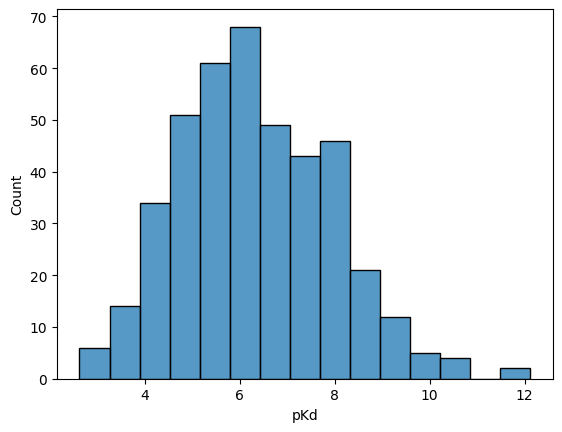

In [40]:
import seaborn as sns

sns.histplot(data=merged, x="pKd")

<Axes: xlabel='Resolution', ylabel='Count'>

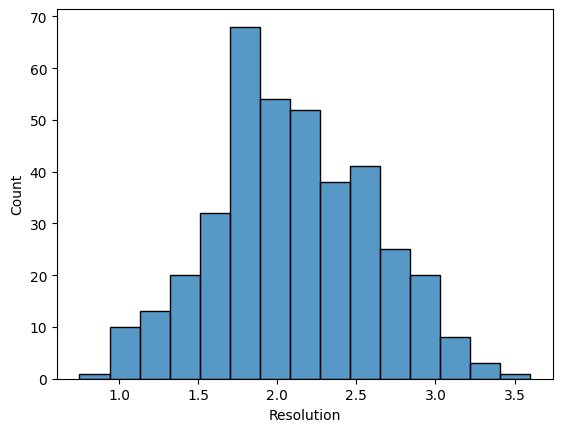

In [ ]:
sns.histplot(data=merged[merged["Resolution"] != "NMR"], x="Resolution")